In [2]:
import os
import sys

paths = [
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl",
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl/myopacus",
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl/torchdp",
    "/your/path/rpdp_fl/experiments",
]

for p in paths:
    if p not in sys.path:
        sys.path.append(p)

# Optional: also update environment variable
os.environ["PYTHONPATH"] = ":".join(sys.path)

In [3]:
from myopacus.accountants.rpdp_utils import GENERATE_EPSILONS_FUNC
import numpy as np
import pandas as pd

DATASET = "fashion_mnist"   # change to "fashion_mnist" when needed

all_results = []

data_types = [
    "iid_10",
    "niid_dir_5",
    "niid_10_5",
    "niid_dir_1",
    "niid_10_2",
]

for dt in data_types:
    results_dir = f"./fed_{DATASET}/{dt}/ditto/"
    file_name = f"{dt}_results_ditto_vanilla_{DATASET}.csv"

    path = os.path.join(results_dir, file_name)

    print(f"Loading: {path}")  # optional debug
    all_results.append(pd.read_csv(path))


/Volumes/Users/shegao_t1/.conda/envs/rpdp/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading: ./fed_fashion_mnist/iid_10/ditto/iid_10_results_ditto_vanilla_fashion_mnist.csv
Loading: ./fed_fashion_mnist/niid_dir_5/ditto/niid_dir_5_results_ditto_vanilla_fashion_mnist.csv
Loading: ./fed_fashion_mnist/niid_10_5/ditto/niid_10_5_results_ditto_vanilla_fashion_mnist.csv
Loading: ./fed_fashion_mnist/niid_dir_1/ditto/niid_dir_1_results_ditto_vanilla_fashion_mnist.csv
Loading: ./fed_fashion_mnist/niid_10_2/ditto/niid_10_2_results_ditto_vanilla_fashion_mnist.csv


This graphs plots comparing Vanilla, Ditto w Global DP, and Ditto w Local DP
for one value of lambda and num_personal_steps

/tmp/ipykernel_927273/1197243102.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lambda'] = df['lambda'].astype(float)


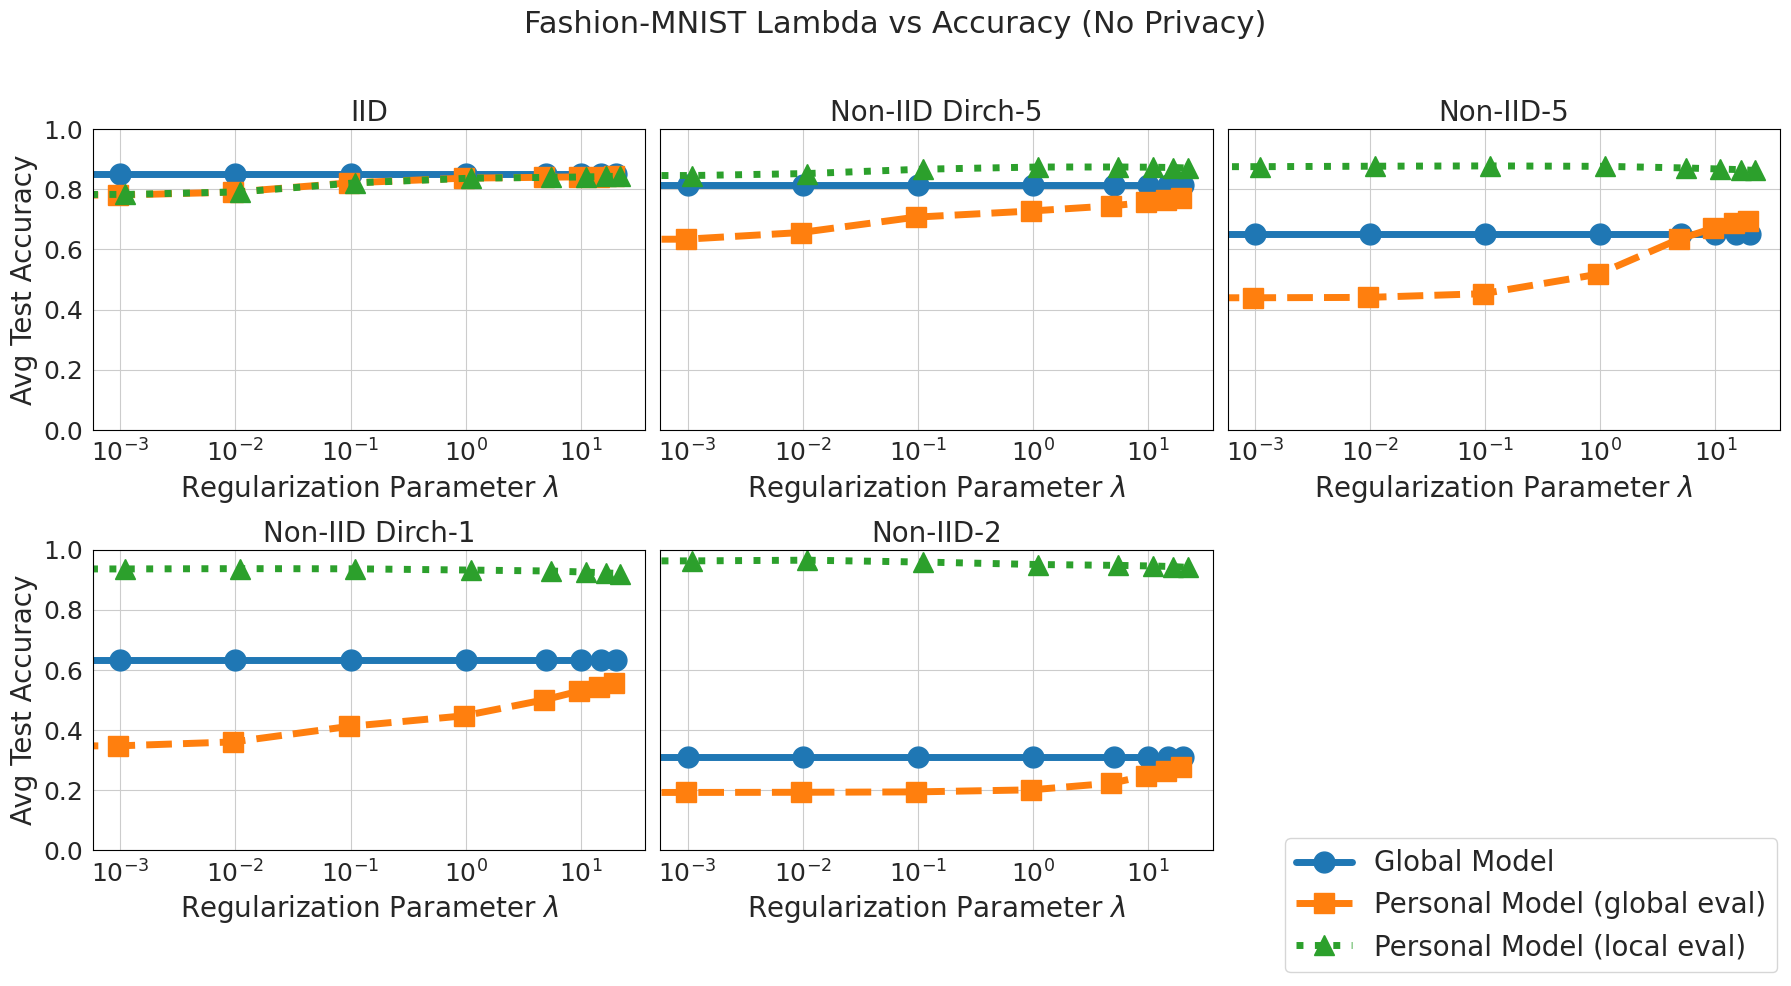

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid', {'axes.linewidth': 1, 'axes.edgecolor': 'black'})

methods = ['global', 'pooled', 'personal']

method_labels = {
    'global': 'Global Model',
    'pooled': 'Personal Model (global eval)',
    'personal': 'Personal Model (local eval)'
}

colors = {
    'global': 'tab:blue',
    'pooled': 'tab:orange',
    'personal': 'tab:green'
}

linestyle_map = {
    'global': '-',        # solid
    'pooled': '--',       # dashed
    'personal': ':'       # dotted
}

marker_map = {
    'global': 'o',   # circle
    'pooled': 's',   # square
    'personal': '^'  # triangle
}

# 'niid_10_2', 'niid_10_5'
if DATASET == "heart_disease":
    datasets= ["niid_10_5"]
    dataset_names = {"niid_10_5" : "Non_IID"}
else:
    datasets = [
        "iid_10",
        "niid_dir_5",
        "niid_10_5",
        "niid_dir_1",
        "niid_10_2",
    ]
    dataset_names = {
    'iid_10': 'IID',
    'niid_10_2': 'Non-IID-2',
    'niid_10_5': 'Non-IID-5',
    'niid_dir_1': 'Non-IID Dirch-1',
    'niid_dir_5': 'Non-IID Dirch-5',
    }


offset_map = {
    'global': 1.0,
    'pooled': 0.96,     # slight left shift
    'personal': 1.10    # slight right shift
}


num_steps = 30

if DATASET == "heart_disease":
    plt.figure(figsize=(7, 5))

else:
    fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
    axs = axs.flatten()


for d_idx, ds in enumerate(datasets):

    ax = axs[d_idx]   

    df = all_results[d_idx]  # assumes correct ordering

    df = df[df['num_personal_steps'] == num_steps]
    df['lambda'] = df['lambda'].astype(float)

    for method in methods:

        df_m = df[df['type'] == method]

        if len(df_m) == 0:
            continue

        df_m = df_m.sort_values(by='lambda')

        x = df_m['lambda'].values * offset_map[method]

        ax.plot(
            x,
            df_m['mean_perf'],
            label=method_labels[method],
            linestyle=linestyle_map[method],
            marker=marker_map[method],
            color=colors[method],
            linewidth=5,
            markersize=15
        )

    ax.set_xscale('log')
    ax.set_title(dataset_names[ds], fontsize=20)
    ax.set_xlabel(r"Regularization Parameter $\lambda$", fontsize=20)
    ax.tick_params(axis='both', labelsize=18)


    if d_idx == 0 or d_idx == 3:
        ax.set_ylabel("Avg Test Accuracy", fontsize=20)
        ax.set_ylim(0.94, 1)
    else:
        ax.set_ylim(0,1)
    ax.grid(True)
   
    
fig.delaxes(axs[5])  # remove empty subplot

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=20)

fig.suptitle("Fashion-MNIST Lambda vs Accuracy (No Privacy)", fontsize=22)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# fig.suptitle("CIFAR10 Lambda vs Accuracy (No Privacy)")
# plt.tight_layout()
plt.show()

In [43]:

from myopacus.accountants.rpdp_utils import GENERATE_EPSILONS_FUNC
import numpy as np
import pandas as pd

DATASET = "heart_disease"   # change to "fashion_mnist" when needed

all_results = []

data_types= ["niid_10_5"]

for dt in data_types:
    results_dir = f"./fed_{DATASET}/{dt}/ditto/"
    file_name = f"{dt}_results_ditto_vanilla_{DATASET}.csv"

    path = os.path.join(results_dir, file_name)

    print(f"Loading: {path}")  # optional debug
    all_results.append(pd.read_csv(path))


Loading: ./fed_heart_disease/niid_10_5/ditto/niid_10_5_results_ditto_vanilla_heart_disease.csv


/tmp/ipykernel_577453/831135647.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['lambda'] = df['lambda'].astype(float)


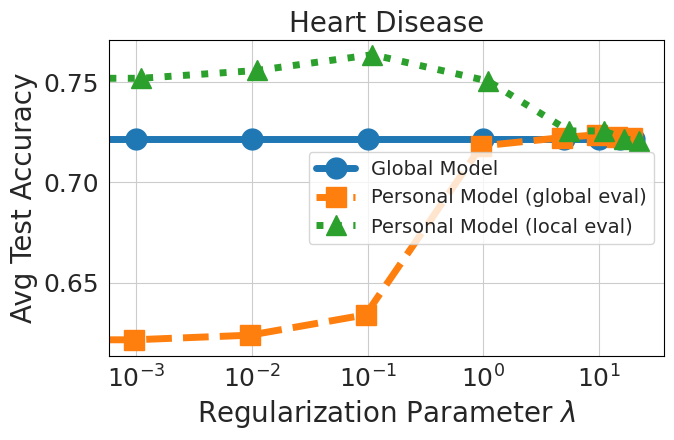

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid', {'axes.linewidth': 1, 'axes.edgecolor': 'black'})

methods = ['global', 'pooled', 'personal']

method_labels = {
    'global': 'Global Model',
    'pooled': 'Personal Model (global eval)',
    'personal': 'Personal Model (local eval)'
}

colors = {
    'global': 'tab:blue',
    'pooled': 'tab:orange',
    'personal': 'tab:green'
}

linestyle_map = {
    'global': '-',
    'pooled': '--',
    'personal': ':'
}

marker_map = {
    'global': 'o',
    'pooled': 's',
    'personal': '^'
}

offset_map = {
    'global': 1.0,
    'pooled': 0.96,
    'personal': 1.10
}

dataset = "niid_10_5"
dataset_name = "Heart Disease"

num_steps = 30

# ========================
# Create single figure
# ========================
fig, ax = plt.subplots(figsize=(7, 5))

df = all_results[0]  # since only one dataset

df = df[df['num_personal_steps'] == num_steps]
df['lambda'] = df['lambda'].astype(float)

for method in methods:

    df_m = df[df['type'] == method]

    if len(df_m) == 0:
        continue

    df_m = df_m.sort_values(by='lambda')

    x = df_m['lambda'].values * offset_map[method]

    ax.plot(
        x,
        df_m['mean_perf'],
        label=method_labels[method],
        linestyle=linestyle_map[method],
        marker=marker_map[method],
        color=colors[method],
        linewidth=5,
        markersize=15
    )

# ========================
# Formatting
# ========================
ax.set_xscale('log')
ax.set_title(dataset_name, fontsize=20)
ax.set_xlabel(r"Regularization Parameter $\lambda$", fontsize=20)
ax.set_ylabel("Avg Test Accuracy", fontsize=20)

ax.tick_params(axis='both', labelsize=18)
ax.grid(True)

ax.legend(fontsize=14)

#fig.suptitle(r"Heart Disease - $\lambda$ vs Accuracy (No Privacy)", fontsize=22)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()